# IFN680 Project 4 - AI Auditing - Case 3 - 'appears young' tagger with a high-confidence bypass

**Student 1:** Karan Rooprai  **Student ID:** n12498122
**Student 2:** Nhu Hieu Nguyen  **Student ID:** n12194778

A social-media tagging system predicts whether a person appears young and attaches a
probability to each prediction. A high-confidence bypass publishes a tag automatically, with no
human review, once that probability passes a fixed threshold. The lab phase looked excellent. In
deployment the system publishes incorrect tags while still reporting near-certainty.

The threshold is stated inconsistently in the material supplied with this project: the assessment
page gives 90 percent and the start-up notebook gives 99 percent. Both are evaluated below and
both are reported, so the finding does not depend on which one is authoritative.

**What this notebook does.** It is an audit, not a repair: the delivered weights are loaded and
never changed, and nothing is retrained. The two supplied test sets are compared on the inputs
themselves before any prediction is made, then on confusion matrices, precision, recall and F1,
predicted-probability distributions, ROC and AUC, reliability and expected calibration error, the
accuracy of the model's most confident predictions, and class activation maps. Section 12 runs the
experiment specific to this case, which is the one that distinguishes the diagnosis in Section 13
from the alternatives.

## 1. Setup

In [1]:
import hashlib
import os
import pickle

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from sklearn.metrics import roc_curve, auc

# Fixed seeds: every sample of images shown below is drawn with a generator seeded here, so the
# figures in the report are the ones this notebook regenerates rather than a fresh random draw.
torch.manual_seed(0)
np.random.seed(0)

# The brief asks for the GPU environment. The model still runs on CPU if no GPU is present, which
# is what makes this notebook portable between the Hub GPU node and a marker's laptop.
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(f'device      : {device}')
print(f'torch       : {torch.__version__}')
print(f'torchvision : {torchvision.__version__}')
print(f'numpy       : {np.__version__}')

device      : cuda:0
torch       : 2.13.0+cu126
torchvision : 0.28.0+cu126
numpy       : 2.5.2


## 2. Locate the delivered model and data

All three cases ship a checkpoint called `resnet_frozen_best.pth`, so the notebook verifies which
one it loaded instead of trusting the file name.

In [2]:
CASE = 3
POSITIVE_CLASS = 'young'

# The three cases ship checkpoints with the SAME file name but different weights. Searching the
# case-scoped folder before the bare name stops a flat unzip from silently loading another case's
# model, and the digest check turns a wrong file into an immediate, readable failure rather than
# a set of plausible but wrong numbers.
EXPECTED_MD5 = '8c64cb4ad0a9107197f8d92aba1413a0'

def find(relative_paths):
    """Return the first candidate path that exists, else None."""
    for path in relative_paths:
        if os.path.exists(path):
            return path
    return None

DATA_ROOT = find([f'Case{CASE}/Case{CASE}Dataset',
                  f'Case{CASE}Dataset',
                  os.path.expanduser(f'~/Assessment4/Case{CASE}/Case{CASE}Dataset'),
                  os.path.expanduser(f'~/Assessment4/Case{CASE}Dataset')])
WEIGHTS = find([f'Case{CASE}/resnet_frozen_best.pth',
                os.path.join(os.path.dirname(DATA_ROOT or '.'), 'resnet_frozen_best.pth'),
                'resnet_frozen_best.pth',
                os.path.expanduser(f'~/Assessment4/Case{CASE}/resnet_frozen_best.pth')])

assert DATA_ROOT, (f'Case{CASE}Dataset not found. Unzip it beside this notebook as '
                   f'Case{CASE}/Case{CASE}Dataset/ and re-run.')
assert WEIGHTS, f'resnet_frozen_best.pth for case {CASE} not found.'
digest = hashlib.md5(open(WEIGHTS, 'rb').read()).hexdigest()
assert digest == EXPECTED_MD5, (f'{WEIGHTS} is not the case {CASE} checkpoint '
                                f'(md5 {digest}, expected {EXPECTED_MD5}).')
print(f'data    : {DATA_ROOT}')
print(f'weights : {WEIGHTS}  (md5 verified)')

data    : /home/n12498122/ifn680/Assessment4/Case3/Case3Dataset
weights : /home/n12498122/ifn680/Assessment4/Case3/resnet_frozen_best.pth  (md5 verified)


## 3. The two test sets

`test_internal` is the validation set the model was developed against; `test_external` is the field
sample where it fails. `positive` means **young**.

In [3]:
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)

# The delivered start-up notebook resizes after ToTensor. antialias is pinned explicitly because
# the default for tensor input changed in torchvision 0.17, and an unpinned resize would make the
# reported numbers depend on the marker's library version rather than on the model.
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Resize((224, 224), antialias=True),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

datasets = {split: torchvision.datasets.ImageFolder(os.path.join(DATA_ROOT, f'test_{split}'),
                                                    transform=transform)
            for split in ('internal', 'external')}
loaders = {split: torch.utils.data.DataLoader(ds, batch_size=32, shuffle=False, num_workers=0)
           for split, ds in datasets.items()}

# ImageFolder assigns indices alphabetically, so negative is 0 and positive is 1. The assert makes
# that a checked fact rather than an assumption every later metric silently depends on.
class_names = datasets['internal'].classes
assert class_names == ['negative', 'positive'], class_names
print(f"class index order : {class_names}   (positive = {POSITIVE_CLASS})")
for split, ds in datasets.items():
    labels = np.array(ds.targets)
    print(f'{split:9s} n={len(ds):4d}   negative={int((labels == 0).sum()):4d}   '
          f'positive={int((labels == 1).sum()):4d}')

class index order : ['negative', 'positive']   (positive = young)
internal  n= 300   negative= 150   positive= 150
external  n= 300   negative= 150   positive= 150


## 4. Audit the inputs before the model

An audit that starts at the confusion matrix can only describe the failure. The question is what
differs between the data the model was validated on and the data it met in deployment, and that is
a property of the images, measurable without a single prediction. Sharpness is summarised by the
variance of the Laplacian, which responds to fine detail and ignores overall level; brightness and
contrast are the mean and standard deviation of pixel intensity.

In [4]:
from PIL import Image

def laplacian_variance(gray):
    """Variance of the discrete Laplacian: a standard, scale-free measure of image sharpness.

    Blurring removes high-frequency detail, which is exactly what the Laplacian responds to, so
    this number falls when an image is smoothed and is insensitive to a change in overall level.
    """
    inner = gray[1:-1, 1:-1]
    lap = (gray[:-2, 1:-1] + gray[2:, 1:-1] + gray[1:-1, :-2] + gray[1:-1, 2:] - 4 * inner)
    return float(lap.var())

def folder_statistics(paths, sample=120, seed=0):
    """Sharpness, brightness, contrast and stored size over a fixed random sample of a folder."""
    rng = np.random.default_rng(seed)
    chosen = [paths[i] for i in rng.choice(len(paths), min(sample, len(paths)), replace=False)]
    sharp, bright, contrast, nbytes, sizes = [], [], [], [], set()
    for path in chosen:
        image = Image.open(path)
        sizes.add(image.size)
        rgb = np.asarray(image.convert('RGB'), dtype=float) / 255.0
        sharp.append(laplacian_variance(np.asarray(image.convert('L'), dtype=float) / 255.0))
        bright.append(rgb.mean())
        contrast.append(rgb.std())
        nbytes.append(os.path.getsize(path))
    return dict(n=len(paths), sharpness=float(np.mean(sharp)), brightness=float(np.mean(bright)),
                contrast=float(np.mean(contrast)), kilobytes=float(np.mean(nbytes)) / 1024,
                sizes=sorted(sizes))

In [5]:
# One row per class folder. The model never sees these raw values; they describe the inputs, which
# is what an audit needs before it looks at any prediction.
paths_by_folder = {}
for split, ds in datasets.items():
    for index, name in enumerate(class_names):
        paths_by_folder[(split, name)] = [p for p, y in ds.samples if y == index]

stats = {key: folder_statistics(paths) for key, paths in paths_by_folder.items()}
print(f"{'folder':26s}{'n':>5}{'sharpness':>12}{'brightness':>12}{'contrast':>10}{'KB':>8}  pixels")
for key in sorted(stats):
    s = stats[key]
    print(f"{key[0] + '/' + key[1]:26s}{s['n']:5d}{s['sharpness']:12.5f}{s['brightness']:12.3f}"
          f"{s['contrast']:10.3f}{s['kilobytes']:8.1f}  {s['sizes'][0][0]}x{s['sizes'][0][1]}")

internal_sharp = np.mean([stats[('internal', c)]['sharpness'] for c in class_names])
external_sharp = np.mean([stats[('external', c)]['sharpness'] for c in class_names])
internal_bright = np.mean([stats[('internal', c)]['brightness'] for c in class_names])
external_bright = np.mean([stats[('external', c)]['brightness'] for c in class_names])
print(f'\nsharpness  internal={internal_sharp:.5f}  external={external_sharp:.5f}  '
      f'ratio={internal_sharp / external_sharp:.1f}x')
print(f'brightness internal={internal_bright:.3f}  external={external_bright:.3f}  '
      f'shift={external_bright - internal_bright:+.3f}')

folder                        n   sharpness  brightness  contrast      KB  pixels
external/negative           150     0.01136       0.418     0.258     6.8  178x218
external/positive           150     0.01185       0.452     0.262     6.8  178x218
internal/negative           150     0.01168       0.433     0.251     6.5  178x218
internal/positive           150     0.00999       0.455     0.256     6.9  178x218

sharpness  internal=0.01083  external=0.01161  ratio=0.9x
brightness internal=0.444  external=0.435  shift=-0.010


### 4.1 Look at the images

Summary statistics can only answer questions that were asked. Displaying every folder is what
catches a difference nobody thought to measure.

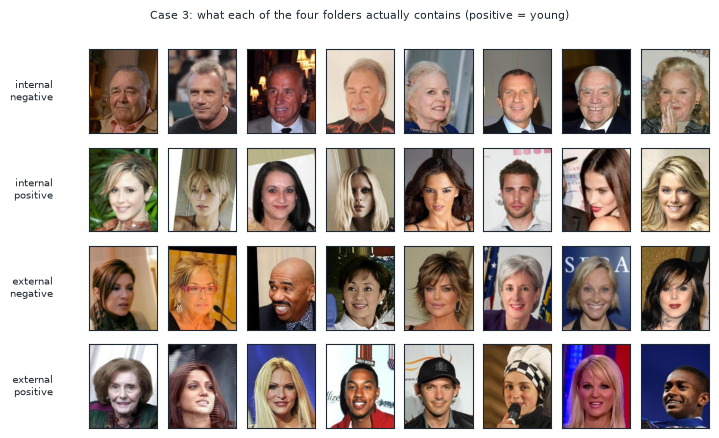

In [6]:
INK, ACCENT, WARM, MUTED, GREEN = '#1f2933', '#2f6f9f', '#c1553b', '#7b8794', '#3f7d58'
plt.rcParams.update({'font.size': 7, 'axes.edgecolor': INK, 'axes.labelcolor': INK,
                     'text.color': INK, 'xtick.color': INK, 'ytick.color': INK,
                     'figure.facecolor': 'white'})

def show_folder(ax_row, split, name, columns, seed=11):
    """Draw one row of raw images from a single class folder."""
    paths = paths_by_folder[(split, name)]
    rng = np.random.default_rng(seed)
    for ax, index in zip(ax_row, rng.choice(len(paths), columns, replace=False)):
        ax.imshow(Image.open(paths[index]))
        ax.set_xticks([]); ax.set_yticks([])

COLUMNS = 8
folders = [(s, c) for s in ('internal', 'external') for c in class_names]
figure, axes = plt.subplots(4, COLUMNS, figsize=(7.2, 4.4))
for row, (split, name) in enumerate(folders):
    show_folder(axes[row], split, name, COLUMNS)
    label = f'{split}\n{name}'
    axes[row][0].set_ylabel(label, fontsize=7, rotation=0, ha='right', va='center', labelpad=26)
figure.suptitle(f'Case {CASE}: what each of the four folders actually contains '
                f'(positive = {POSITIVE_CLASS})', fontsize=8)
figure.tight_layout(rect=(0.0, 0.0, 1.0, 0.97))
figure.savefig(f'case{CASE}_composition.png', dpi=150, bbox_inches='tight')
figure.savefig(f'case{CASE}_composition.pdf', bbox_inches='tight')
plt.show()

## 5. The delivered model

A ResNet-18 with its 1000-way ImageNet head replaced by a two-way one, trained by the previous
team. Loaded once, put in evaluation mode, and left unmodified for the rest of the notebook.

In [7]:
def setup_model(model, num_classes, freeze_backbone=False):
    """Swap in a head with num_classes outputs. Reproduced from the supplied start-up notebook."""
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    if freeze_backbone:
        for parameter in model.parameters():
            parameter.requires_grad = False
        for parameter in model.fc.parameters():
            parameter.requires_grad = True
    return model

# weights=None builds the architecture without downloading ImageNet weights: every parameter is
# replaced by the delivered checkpoint on the next line. Nothing here trains or alters the model.
model = setup_model(torchvision.models.resnet18(weights=None), 2)
model.load_state_dict(torch.load(WEIGHTS, map_location=device, weights_only=True))
model = model.to(device).eval()
print(f'loaded ResNet-18 with a {model.fc.out_features}-way head, in eval mode')

loaded ResNet-18 with a 2-way head, in eval mode


## 6. Predictions

One pass over each split, recording the true label and the probability assigned to the positive
class. Every number and figure below is computed from these two arrays.

In [8]:
@torch.no_grad()
def collect(loader):
    """Return ground-truth labels and P(positive) for every image the loader yields, in order."""
    labels, probabilities = [], []
    for inputs, targets in loader:
        probabilities.append(torch.softmax(model(inputs.to(device)), dim=1)[:, 1].cpu().numpy())
        labels.append(targets.numpy())
    return np.concatenate(labels), np.concatenate(probabilities)

# Every metric, figure and table below is derived from these two arrays, so the audit is fully
# reproducible from the pickle even without a GPU.
results = {}
for split, loader in loaders.items():
    labels, probabilities = collect(loader)
    results[split] = {'labels': labels, 'prob_pos': probabilities}
    print(f'{split:9s} n={len(labels):4d}   '
          f'accuracy={(((probabilities > 0.5).astype(int) == labels).mean()):.4f}')

with open(f'case{CASE}_predictions.pkl', 'wb') as handle:
    pickle.dump(results, handle)
print(f'wrote case{CASE}_predictions.pkl')

internal  n= 300   accuracy=0.9733
external  n= 300   accuracy=0.5933
wrote case3_predictions.pkl


## 7. Confusion matrices and per-split metrics

Accuracy compresses two very different quantities into one. Precision and recall separate them,
and their gap is what shows whether the errors fall on one side.

In [9]:
def counts(labels, probabilities, threshold=0.5):
    """True/false positive and negative counts at a decision threshold."""
    predicted, actual = probabilities > threshold, labels.astype(bool)
    return (int((predicted & actual).sum()), int((predicted & ~actual).sum()),
            int((~predicted & ~actual).sum()), int((~predicted & actual).sum()))

def metrics(labels, probabilities):
    """Accuracy, precision, recall, F1, AUC and expected calibration error for one split."""
    tp, fp, tn, fn = counts(labels, probabilities)
    accuracy = (tp + tn) / (tp + fp + tn + fn)
    precision = tp / (tp + fp) if tp + fp else float('nan')
    recall = tp / (tp + fn) if tp + fn else float('nan')
    f1 = 2 * precision * recall / (precision + recall) if precision + recall else float('nan')
    false_positive_rate, true_positive_rate, _ = roc_curve(labels, probabilities)
    return dict(acc=accuracy, prec=precision, rec=recall, f1=f1,
                auc=auc(false_positive_rate, true_positive_rate), ece=expected_calibration_error(
                    labels, probabilities)[3], tp=tp, fp=fp, tn=tn, fn=fn)

def expected_calibration_error(labels, probabilities, bins=10):
    """Bin predictions by confidence and compare accuracy against confidence within each bin.

    Confidence is max(p, 1-p): how sure the model is of whichever class it chose. A calibrated
    model is right about c of the time among predictions made with confidence c, so ECE is the
    sample-weighted gap between the two, and it is the number a reliability diagram summarises.
    """
    confidence = np.maximum(probabilities, 1 - probabilities)
    correct = ((probabilities > 0.5).astype(int) == labels).astype(float)
    edges = np.linspace(0, 1, bins + 1)
    which = np.clip(np.digitize(confidence, edges) - 1, 0, bins - 1)
    accuracy = np.array([correct[which == b].mean() if (which == b).any() else np.nan
                         for b in range(bins)])
    mean_confidence = np.array([confidence[which == b].mean() if (which == b).any() else np.nan
                                for b in range(bins)])
    weight = np.array([(which == b).sum() for b in range(bins)], dtype=float)
    return mean_confidence, accuracy, weight, float(
        np.nansum(weight / weight.sum() * np.abs(accuracy - mean_confidence)))

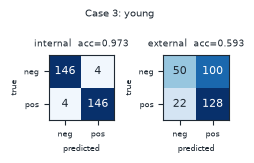

split          acc    prec     rec      F1      AUC     ECE    TP   FP   TN   FN
internal     0.973   0.973   0.973   0.973   0.9960   0.036   146    4  146    4
external     0.593   0.561   0.853   0.677   0.5641   0.296   128  100   50   22


In [10]:
def draw_confusion(ax, labels, probabilities, title):
    """Confusion matrix with the count printed in every cell.

    A heatmap alone shows the shape of the errors; the counts are what the written analysis
    quotes, so they belong inside the figure rather than in a separate printout.
    """
    tp, fp, tn, fn = counts(labels, probabilities)
    matrix = np.array([[tn, fp], [fn, tp]])
    ax.imshow(matrix, cmap='Blues', vmin=0, vmax=matrix.max())
    for row in range(2):
        for column in range(2):
            value = matrix[row, column]
            ax.text(column, row, f'{value}', ha='center', va='center', fontsize=8,
                    color='white' if value > matrix.max() * 0.55 else INK)
    short = [name[:3] for name in class_names]
    ax.set_xticks([0, 1], short, fontsize=6); ax.set_yticks([0, 1], short, fontsize=6)
    ax.set_xlabel('predicted', fontsize=6); ax.set_ylabel('true', fontsize=6)
    ax.set_title(title, fontsize=6.5)

scores = {split: metrics(results[split]['labels'], results[split]['prob_pos'])
          for split in results}

# Drawn at 2.4 inches because that is roughly the width it occupies in the report. A figure scaled
# down from 7 inches into a column has labels nobody can read.
figure, axes = plt.subplots(1, 2, figsize=(2.4, 1.5))
for ax, split in zip(axes, ('internal', 'external')):
    draw_confusion(ax, results[split]['labels'], results[split]['prob_pos'],
                   f"{split}  acc={scores[split]['acc']:.3f}")
figure.suptitle(f'Case {CASE}: {POSITIVE_CLASS}', fontsize=7)
figure.tight_layout(rect=(0.0, 0.0, 1.0, 0.94))
figure.savefig(f'case{CASE}_confusion.png', dpi=150, bbox_inches='tight')
figure.savefig(f'case{CASE}_confusion.pdf', bbox_inches='tight')
plt.show()

header = f"{'split':10s}{'acc':>8}{'prec':>8}{'rec':>8}{'F1':>8}{'AUC':>9}{'ECE':>8}"
print(header + f"{'TP':>6}{'FP':>5}{'TN':>5}{'FN':>5}")
for split in ('internal', 'external'):
    s = scores[split]
    # AUC at four places: three would round 0.9997 to a perfect 1.000 and overstate the result.
    print(f"{split:10s}{s['acc']:8.3f}{s['prec']:8.3f}{s['rec']:8.3f}{s['f1']:8.3f}"
          f"{s['auc']:9.4f}{s['ece']:8.3f}{s['tp']:6d}{s['fp']:5d}{s['tn']:5d}{s['fn']:5d}")

## 8. Where the predicted probabilities sit

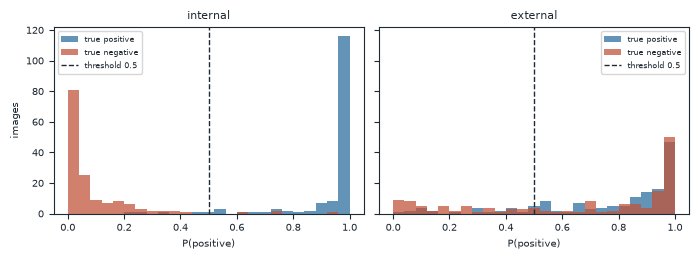

In [11]:
# A classifier that has kept its grip pushes the two classes to opposite ends of the axis. Mass
# collapsing to the middle, or one class crossing the threshold, localises what went wrong.
figure, axes = plt.subplots(1, 2, figsize=(7.0, 2.6), sharey=True)
for ax, split in zip(axes, ('internal', 'external')):
    labels = results[split]['labels'].astype(bool)
    probabilities = results[split]['prob_pos']
    ax.hist(probabilities[labels], bins=25, range=(0, 1), alpha=0.75, color=ACCENT,
            label=f'true {class_names[1]}')
    ax.hist(probabilities[~labels], bins=25, range=(0, 1), alpha=0.75, color=WARM,
            label=f'true {class_names[0]}')
    ax.axvline(0.5, color=INK, ls='--', lw=1, label='threshold 0.5')
    ax.set_title(split, fontsize=8); ax.set_xlabel(f'P({class_names[1]})')
    ax.legend(fontsize=6)
axes[0].set_ylabel('images')
figure.tight_layout()
figure.savefig(f'case{CASE}_prob_dist.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. ROC and AUC

Accuracy and the confusion matrix both depend on the 0.5 threshold. AUC does not, so comparing the
two tells whether the model has lost the ability to separate the classes or merely to place the
boundary.

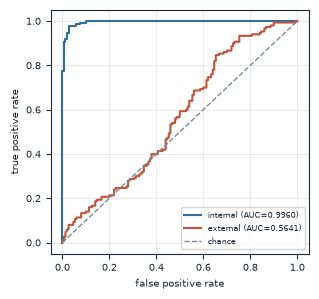

AUC internal=0.9960   external=0.5641


In [12]:
# ROC is threshold-free, so it separates "the scores no longer rank the classes" from "the scores
# still rank them but 0.5 is now the wrong place to cut".
figure, ax = plt.subplots(figsize=(3.2, 3.0))
for split, colour in (('internal', ACCENT), ('external', WARM)):
    false_positive_rate, true_positive_rate, _ = roc_curve(results[split]['labels'],
                                                           results[split]['prob_pos'])
    ax.plot(false_positive_rate, true_positive_rate, color=colour,
            label=f"{split} (AUC={scores[split]['auc']:.4f})")
ax.plot([0, 1], [0, 1], color=MUTED, ls='--', lw=1, label='chance')
ax.set_xlabel('false positive rate'); ax.set_ylabel('true positive rate')
ax.legend(fontsize=6); ax.grid(alpha=0.25)
figure.tight_layout()
figure.savefig(f'case{CASE}_roc.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"AUC internal={scores['internal']['auc']:.4f}   "
      f"external={scores['external']['auc']:.4f}")

## 10. Calibration, and what the most confident predictions are worth

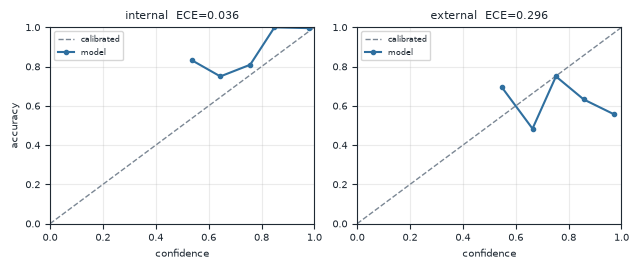

split        gate  published  accuracy
internal     0.90      81.0%     0.996
internal     0.99      42.3%     1.000
external     0.90      54.3%     0.558
external     0.99      20.0%     0.517


In [13]:
figure, axes = plt.subplots(1, 2, figsize=(6.4, 2.7))
for ax, split in zip(axes, ('internal', 'external')):
    mean_confidence, accuracy, weight, ece = expected_calibration_error(
        results[split]['labels'], results[split]['prob_pos'])
    ax.plot([0, 1], [0, 1], color=MUTED, ls='--', lw=1, label='calibrated')
    ax.plot(mean_confidence, accuracy, marker='o', ms=3, color=ACCENT, label='model')
    ax.set_title(f'{split}  ECE={ece:.3f}', fontsize=8)
    ax.set_xlabel('confidence'); ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.legend(fontsize=6); ax.grid(alpha=0.25)
axes[0].set_ylabel('accuracy')
figure.tight_layout()
figure.savefig(f'case{CASE}_reliability.png', dpi=150, bbox_inches='tight')
plt.show()

# The number the bypass design actually depends on: among predictions the gate would publish
# without review, how many are right?
print(f"{'split':10s}{'gate':>7}{'published':>11}{'accuracy':>10}")
for split in ('internal', 'external'):
    labels, probabilities = results[split]['labels'], results[split]['prob_pos']
    confidence = np.maximum(probabilities, 1 - probabilities)
    correct = (probabilities > 0.5).astype(int) == labels
    for gate in (0.90, 0.99):
        selected = confidence >= gate
        accuracy = correct[selected].mean() if selected.any() else float('nan')
        print(f'{split:10s}{gate:7.2f}{selected.mean() * 100:10.1f}%{accuracy:10.3f}')

### 10.1 Accuracy against coverage

Sorting predictions by confidence and taking a running accuracy traces every operating point a
confidence threshold can reach, which is the quantity a review-bypass depends on.

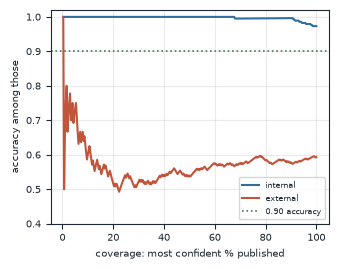

split       coverage  accuracy
internal         10%     1.000
internal         25%     1.000
internal         50%     1.000
internal        100%     0.973
internal    best accuracy at any coverage above 5%: 1.000
external         10%     0.600
external         25%     0.533
external         50%     0.540
external        100%     0.593
external    best accuracy at any coverage above 5%: 0.750


In [14]:
def risk_coverage(labels, probabilities):
    """Accuracy achievable if only the most confident fraction of predictions is acted on.

    Sorting by confidence and taking a running mean of correctness traces every operating point
    a confidence gate can reach. Because any calibration is monotone in the score, it moves the
    threshold that selects a coverage but never this curve, so the curve is the real ceiling.
    """
    confidence = np.maximum(probabilities, 1 - probabilities)
    correct = ((probabilities > 0.5).astype(int) == labels).astype(float)
    order = np.argsort(-confidence)
    coverage = np.arange(1, len(labels) + 1) / len(labels)
    return coverage, np.cumsum(correct[order]) / np.arange(1, len(labels) + 1)

figure, ax = plt.subplots(figsize=(3.4, 2.7))
for split, colour in (('internal', ACCENT), ('external', WARM)):
    coverage, accuracy = risk_coverage(results[split]['labels'], results[split]['prob_pos'])
    ax.plot(coverage * 100, accuracy, color=colour, label=split)
ax.axhline(0.90, color=GREEN, ls=':', lw=1.2, label='0.90 accuracy')
ax.set_xlabel('coverage: most confident % published'); ax.set_ylabel('accuracy among those')
ax.set_ylim(0.4, 1.02); ax.legend(fontsize=6); ax.grid(alpha=0.25)
figure.tight_layout()
figure.savefig(f'case{CASE}_risk_coverage.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"{'split':10s}{'coverage':>10}{'accuracy':>10}")
for split in ('internal', 'external'):
    coverage, accuracy = risk_coverage(results[split]['labels'], results[split]['prob_pos'])
    for target in (0.10, 0.25, 0.50, 1.00):
        # ceil rather than searchsorted: the point at exactly this coverage, not the one below it.
        index = max(0, int(np.ceil(target * len(coverage))) - 1)
        print(f'{split:10s}{coverage[index] * 100:9.0f}%{accuracy[index]:10.3f}')
    best = accuracy[coverage >= 0.05].max()
    print(f'{split:10s}  best accuracy at any coverage above 5%: {best:.3f}')

## 11. Class activation maps

Metrics say how often the model is wrong. CAM shows what it was looking at when it was, which is
the evidence that separates a model attending to the target attribute from one keying on
something that merely accompanies it.

In [15]:
# Class activation mapping, as in the week 5 tutorial: the last convolutional block's feature maps
# weighted by the classifier weights for the predicted class, which shows which regions of the
# image drove that prediction.
features = {}
model.layer4[1].register_forward_hook(
    lambda module, inputs, output: features.__setitem__('maps', output.detach()))
head_weights = model.state_dict()['fc.weight']

@torch.no_grad()
def class_activation_map(image):
    """Return the predicted class, its confidence, and the upsampled activation map."""
    logits = model(image.unsqueeze(0).to(device))
    predicted = int(logits.argmax(1))
    confidence = float(torch.softmax(logits, 1).max())
    cam = torch.sum(head_weights[predicted][:, None, None] * features['maps'][0], dim=0)
    cam = cam.clamp(min=0)
    cam = cam / (cam.max() + 1e-8)
    cam = torch.nn.functional.interpolate(cam[None, None], size=(224, 224), mode='bilinear',
                                          align_corners=False)
    return predicted, confidence, cam.squeeze().cpu().numpy()

def denormalise(image):
    """Undo the ImageNet normalisation so the tensor can be displayed."""
    return np.clip(image.numpy().transpose(1, 2, 0) * IMAGENET_STD + IMAGENET_MEAN, 0, 1)

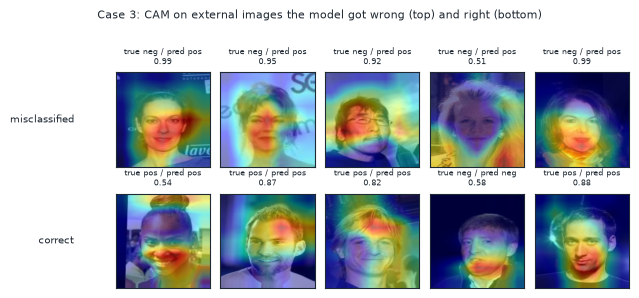

external errors: 122 of 300


In [16]:
# Sampling at random would show whatever the model happens to be doing on average. The question is
# what it does when it is WRONG, so the two rows are drawn from the errors and from the correct
# predictions on the same split and the same true class.
external = datasets['external']
labels, probabilities = results['external']['labels'], results['external']['prob_pos']
predicted_labels = (probabilities > 0.5).astype(int)
wrong = np.where(predicted_labels != labels)[0]
right = np.where(predicted_labels == labels)[0]

COLUMNS = 5
rng = np.random.default_rng(3)
groups = [('misclassified', rng.choice(wrong, min(COLUMNS, len(wrong)), replace=False)),
          ('correct', rng.choice(right, min(COLUMNS, len(right)), replace=False))]
figure, axes = plt.subplots(2, COLUMNS, figsize=(6.4, 3.0))
for row, (title, indices) in enumerate(groups):
    for ax, index in zip(axes[row], indices):
        image, true_label = external[index]
        predicted, confidence, cam = class_activation_map(image)
        ax.imshow(denormalise(image))
        ax.imshow(cam, cmap='jet', alpha=0.45)
        ax.set_xticks([]); ax.set_yticks([])
        ax.set_title(f'true {class_names[true_label][:3]} / pred {class_names[predicted][:3]}'
                     f'\n{confidence:.2f}', fontsize=6)
    axes[row][0].set_ylabel(title, fontsize=7, rotation=0, ha='right', va='center', labelpad=30)
figure.suptitle(f'Case {CASE}: CAM on external images the model got wrong (top) and right (bottom)',
                fontsize=8)
figure.tight_layout(rect=(0.0, 0.0, 1.0, 0.95))
figure.savefig(f'case{CASE}_cam.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'external errors: {len(wrong)} of {len(labels)}')

In [17]:
# CelebA images are aligned, so the same pixel rows hold the same part of every face: the eyes sit
# just above the middle and the jaw near the bottom. Splitting the activation map into three bands
# and averaging over many images turns "where is it looking" into a number that can be compared
# between the predictions the model got right and the ones it got wrong.
BANDS = [('forehead and hair', 0, 75), ('eyes and nose', 75, 150), ('mouth and jaw', 150, 224)]

def band_mass(indices, dataset, limit=60):
    """Mean share of activation-map mass falling in each horizontal band of the face."""
    totals = np.zeros(len(BANDS))
    for index in indices[:limit]:
        image, _ = dataset[int(index)]
        _, _, cam = class_activation_map(image)
        share = np.array([cam[low:high].sum() for _, low, high in BANDS])
        totals += share / share.sum()
    return totals / min(limit, len(indices))

print(f"{'external predictions':22s}" + ''.join(f'{name:>20}' for name, _, _ in BANDS))
for title, indices in (('misclassified', wrong), ('correct', right)):
    shares = band_mass(indices, external)
    print(f'{title:22s}' + ''.join(f'{value:20.3f}' for value in shares))

external predictions     forehead and hair       eyes and nose       mouth and jaw
misclassified                        0.243               0.411               0.345
correct                              0.153               0.427               0.421


## 12. Can recalibration rescue the bypass?

Calibration is a monotone transformation of the score: it relabels the confidence axis
without changing the order in which examples are ranked. So it can move the numbers printed on a
reliability diagram, but it cannot change which examples are the most confident, and therefore it
cannot change the accuracy achievable at any given coverage.

Two experiments follow. The first fits a temperature on one half of the external set and measures
ECE and AUC on the other half, so the improvement is measured out of sample rather than assumed.
The second sweeps every threshold to trace the accuracy actually reachable at each coverage, which
is what decides whether an auto-publish gate can exist at all.

In [18]:
def temperature_scale(logit_gap, temperature):
    """Softmax temperature applied to a two-class problem, which reduces to one logit gap."""
    return 1.0 / (1.0 + np.exp(-logit_gap / temperature))

def negative_log_likelihood(labels, probabilities):
    clipped = np.clip(probabilities, 1e-7, 1 - 1e-7)
    return float(-(labels * np.log(clipped) + (1 - labels) * np.log(1 - clipped)).mean())

# Fit on one half of the external set and measure on the other, so the improvement is out of
# sample. Fitting and reporting on the same images would flatter the result.
labels, probabilities = results['external']['labels'], results['external']['prob_pos']
gap = np.log(np.clip(probabilities, 1e-7, 1 - 1e-7) / np.clip(1 - probabilities, 1e-7, 1 - 1e-7))
rng = np.random.default_rng(0)
order = rng.permutation(len(labels))
fit, held = order[:len(order) // 2], order[len(order) // 2:]

grid = np.linspace(0.2, 20.0, 400)
TEMPERATURE = float(grid[np.argmin([negative_log_likelihood(labels[fit],
                                                            temperature_scale(gap[fit], t))
                                    for t in grid])])
calibrated = temperature_scale(gap[held], TEMPERATURE)
before = metrics(labels[held], probabilities[held])
after = metrics(labels[held], calibrated)
print(f'fitted temperature T = {TEMPERATURE:.2f} on {len(fit)} images, '
      f'measured on the other {len(held)}')
print(f"{'':14s}{'ECE':>8}{'AUC':>8}{'accuracy':>10}{'max confidence':>16}")
for name, values, probs in (('uncalibrated', before, probabilities[held]),
                            ('calibrated', after, calibrated)):
    print(f"{name:14s}{values['ece']:8.3f}{values['auc']:8.3f}{values['acc']:10.3f}"
          f'{np.maximum(probs, 1 - probs).max():16.3f}')

fitted temperature T = 12.16 on 150 images, measured on the other 150
                   ECE     AUC  accuracy  max confidence
uncalibrated     0.326   0.544     0.593           1.000
calibrated       0.070   0.544     0.593           0.687


Temperature scaling divides the logit by a constant. That is monotone, so
it cannot reorder predictions: AUC is unchanged by construction and the check above confirms it
numerically. What it does change is the confidence attached to each prediction, and therefore how
many predictions clear the gate.

In [19]:
# What the bypass would actually publish, before and after calibration, at both stated thresholds.
print(f"{'gate':>6}{'uncalibrated published':>26}{'accuracy':>10}"
      f"{'calibrated published':>24}{'accuracy':>10}")
for gate in (0.90, 0.99):
    row = [f'{gate:6.2f}']
    for probs in (probabilities[held], calibrated):
        confidence = np.maximum(probs, 1 - probs)
        correct = (probs > 0.5).astype(int) == labels[held]
        selected = confidence >= gate
        published = f'{selected.sum()} of {len(held)}'
        accuracy = f'{correct[selected].mean():.3f}' if selected.any() else 'n/a'
        row += [f'{published:>26}' if len(row) == 1 else f'{published:>24}', f'{accuracy:>10}']
    print(''.join(row))

coverage, accuracy_curve = risk_coverage(labels, probabilities)
reachable = accuracy_curve[coverage >= 0.02].max()
print(f'\nbest accuracy reachable at any coverage above 2% : {reachable:.3f}')
print(f'a gate that publishes at 0.90 accuracy therefore '
      f"{'exists' if reachable >= 0.90 else 'does not exist'} on this data")

  gate    uncalibrated published  accuracy    calibrated published  accuracy
  0.90                 81 of 150     0.543                0 of 150       n/a
  0.99                 32 of 150     0.500                0 of 150       n/a

best accuracy reachable at any coverage above 2% : 0.778
a gate that publishes at 0.90 accuracy therefore does not exist on this data


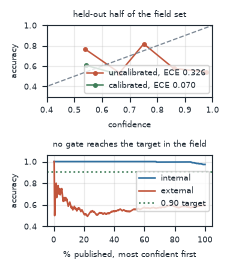

In [20]:
# The report panel for this case: calibration measured out of sample, above the ceiling on accuracy
# that no threshold and no rescaling can cross. Drawn at the width the report gives it.
figure, axes = plt.subplots(2, 1, figsize=(2.3, 2.7))

for name, probs, colour in (('uncalibrated', probabilities[held], WARM),
                            ('calibrated', calibrated, GREEN)):
    mean_confidence, accuracy_bins, _, ece = expected_calibration_error(labels[held], probs)
    axes[0].plot(mean_confidence, accuracy_bins, marker='o', ms=2.5, lw=1.1, color=colour,
                 label=f'{name}, ECE {ece:.3f}')
axes[0].plot([0, 1], [0, 1], color=MUTED, ls='--', lw=0.9)
axes[0].set_xlabel('confidence', fontsize=6); axes[0].set_ylabel('accuracy', fontsize=6)
axes[0].set_xlim(0.4, 1.0); axes[0].set_ylim(0.3, 1.0)
axes[0].legend(fontsize=5.5, loc='lower right'); axes[0].grid(alpha=0.25)
axes[0].tick_params(labelsize=6)
axes[0].set_title('held-out half of the field set', fontsize=6)

for split, colour in (('internal', ACCENT), ('external', WARM)):
    coverage_curve, accuracy_curve = risk_coverage(results[split]['labels'],
                                                   results[split]['prob_pos'])
    axes[1].plot(coverage_curve * 100, accuracy_curve, color=colour, lw=1.2, label=split)
axes[1].axhline(0.90, color=GREEN, ls=':', lw=1.2, label='0.90 target')
axes[1].set_xlabel('% published, most confident first', fontsize=6)
axes[1].set_ylabel('accuracy', fontsize=6)
axes[1].set_ylim(0.4, 1.06); axes[1].legend(fontsize=5.5, loc='center right', ncol=1)
axes[1].grid(alpha=0.25); axes[1].tick_params(labelsize=6)
axes[1].set_title('no gate reaches the target in the field', fontsize=6)

figure.tight_layout()
figure.savefig(f'case{CASE}_evidence.png', dpi=200, bbox_inches='tight')
figure.savefig(f'case{CASE}_evidence.pdf', bbox_inches='tight')
plt.show()

## 13. Findings

**Diagnosis: overconfidence under distribution shift.** The model does not transfer to the
deployed population and its confidence does not reveal it; validating on an unrepresentative
internal set is the cause.

**Experiments and evidence.** The internal set contrasts clearly elderly faces against young adults, which is a far
easier problem than the one deployment poses, where the negatives are middle-aged. On that easy
split the model reaches AUC 0.996 and looks well calibrated. On field data AUC falls to 0.564,
which is close to chance: the scores no longer rank the classes. The softmax nevertheless keeps
producing extreme probabilities, so ECE rises from 0.036 to 0.296 and the reliability curve sits
far below the diagonal.

The consequence for the bypass is direct. Among external predictions issued at 0.90 confidence or
above, barely more than half are correct, and raising the gate to 0.99 does not help, because the
confidence that selects them is no longer informative about whether they are right. Both thresholds
are reported because the assessment page and the supplied notebook state different ones; the
conclusion is the same at either.

Fitting a temperature on half the external set and measuring on the other half confirms
what the theory requires: expected calibration error falls substantially while AUC does not move at
all, because dividing a logit by a constant is monotone and cannot reorder predictions. The
practical consequence is stark. After calibration no field image reaches even 0.70 confidence, so
the bypass at either stated threshold would publish nothing at all. The risk-coverage curve says
the same thing from the other direction: it traces the accuracy reachable at every coverage, and no
operating point on the field curve reaches 0.90.

**Recommendations.** Switch the bypass off rather than re-tuning its threshold. The curve shows
there is no threshold at which the model publishes at 90% accuracy on this population, so any
number chosen for the gate would trade volume for errors rather than avoid them. Recalibrate, but
treat it as instrumentation rather than a fix: a calibrated score is what lets monitoring detect
this condition, and after scaling almost nothing clears the gate, which is the honest reading.
Rebuild the internal validation set so its negatives span the ages the system actually meets, and
monitor ECE and the accuracy of high-confidence predictions continuously, since both were healthy
in the lab and neither stayed so.